# Example 3: fitting with a Gaussian Process (K2-229)

In this notebook, we will fit the two-planet system K2-229 both without and with a Gaussian Process (GP), to demonstrate how GPs can be essential for modelling correlated noise from stellar activity. This example builds on [Example 1: fitting a single planet](https://ravest.readthedocs.io/en/latest/Examples/example_1_fitting.html) and [Example 2: fitting a two-planet system](https://ravest.readthedocs.io/en/latest/Examples/example_2_K2-24.html), so we focus on what's new: setting up and fitting a GP.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ravest.prior
from ravest.fit import Fitter
from ravest.model import calculate_mpsini
from ravest.param import Parameter, Parameterisation

> **Important:** to keep this example quick to run and its outputs reproducible, it takes two shortcuts that you should **not** copy in your own fits:
>
> - **Few walkers and short chains.** The MCMC runs here use far fewer walkers, and far fewer steps, than a real fit would. Ravest requires at least $2\times$ the number of free parameters; for real fits a couple of hundred walkers is a sensible starting point, and you should run until the chains have converged (e.g. `check_convergence=True` in `run_mcmc`).
> - **A fixed random seed.** The next cell (collapsed on the website) fixes NumPy's random seed so that re-running this notebook gives identical results. **Remove it in your own fits: never freeze the random seed for real analysis.**

In [ ]:
# WARNING: this fixes NumPy's random seed ONLY so this tutorial's outputs are reproducible.
# Do NOT copy this into your own fits: remove it, and do not freeze the random seed.
np.random.seed(42)

## Load and inspect the RV data

The data for K2-229 was used in [Osborne et al. (2025), A&A, 693, A4](https://ui.adsabs.harvard.edu/abs/2025A%26A...693A...4O/abstract) and downloaded from [VizieR J/A+A/693/A4](https://doi.org/10.26093/cds/vizier.36930004).

In [ ]:
fpath = Path.cwd() / "example_data" / "K2-229.csv"
data = pd.read_csv(fpath)
data

,BJD,RV,e_RV,FWHM,BIS,System,TIC,GaiaDR2,tel
0,2.457798e+06,22965.967262,1.580978,0.002236,0.002236,K2-229,98720809,3583630929786305280,HARPS
1,2.457798e+06,22971.043308,1.471306,0.002081,0.002081,K2-229,98720809,3583630929786305280,HARPS
2,2.457797e+06,22963.492334,1.562922,0.002210,0.002210,K2-229,98720809,3583630929786305280,HARPS
3,2.457797e+06,22967.865369,1.499985,0.002121,0.002121,K2-229,98720809,3583630929786305280,HARPS
4,2.457796e+06,22970.042232,1.363895,0.001929,0.001929,K2-229,98720809,3583630929786305280,HARPS
...,...,...,...,...,...,...,...,...,...
115,2.457803e+06,22992.061104,1.902412,0.002690,0.002690,K2-229,98720809,3583630929786305280,HARPS
116,2.457803e+06,22986.700197,1.512577,0.002139,0.002139,K2-229,98720809,3583630929786305280,HARPS
117,2.457803e+06,22988.074353,1.580983,0.002236,0.002236,K2-229,98720809,3583630929786305280,HARPS
118,2.457802e+06,22988.311991,1.448587,0.002049,0.002049,K2-229,98720809,3583630929786305280,HARPS


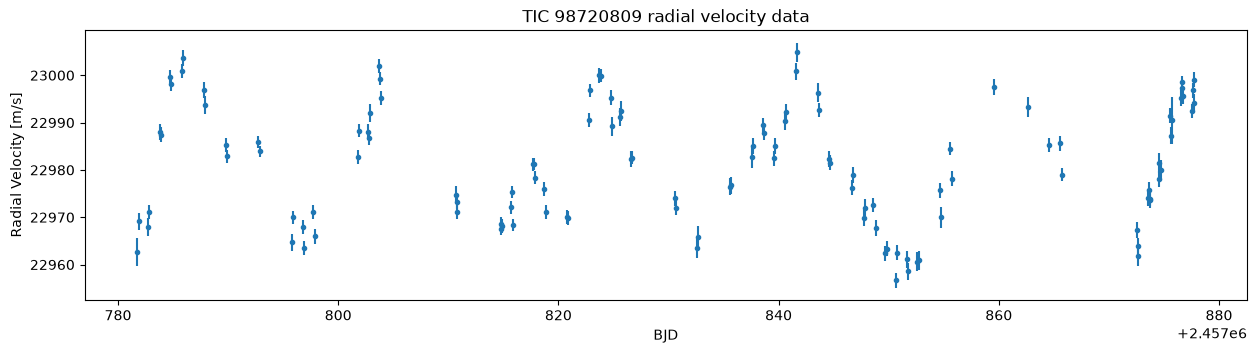

In [ ]:
plt.figure(figsize=(15,3.5))
plt.title("TIC 98720809 radial velocity data")
plt.ylabel("Radial Velocity [m/s]")
plt.xlabel("BJD")
plt.errorbar(data["BJD"], data["RV"], yerr=data["e_RV"], marker=".", linestyle="None")
plt.show()

---

## Fitting without a GP (white-noise model)

For more details on fitting a white noise model, see [Example 1: fitting a single planet](https://ravest.readthedocs.io/en/latest/Examples/example_1_fitting.html).

### Set up the `Fitter`

Note that we truncate the BJD times to BTJD (Barycentric TESS Julian Date) by subtracting 2457000 (this is done mostly to make plot labels and $T_\text{C}$ values more readable!)

In [ ]:
parameterisation=Parameterisation("P K e w Tc")
fitter = Fitter(planet_letters=["b","c"], parameterisation=parameterisation)
fitter.add_data(
                time=(data["BJD"].to_numpy()-2457000), 
                vel=data["RV"].to_numpy(),
                velerr=data["e_RV"].to_numpy(),
                instrument=data["tel"].to_numpy(),
                t0=np.mean(data["BJD"].to_numpy()-2457000),
)
fitter

Construct the parameters dict. The values for $P$ and $T_\text{C}$ are the reported values from Supplementary Table 6 of [Santerne et al. 2018](https://ui.adsabs.harvard.edu/abs/2018NatAs...2..393S/abstract). For the sake of making this notebook run quickly, we use their reported values as starting points.

In [ ]:
# Construct the params dict
params = {
          "P_b": Parameter(0.584249, fixed=False),
          "K_b": Parameter(10, fixed=False),
          "e_b": Parameter(0, fixed=True),
          "w_b": Parameter(np.pi/2, fixed=True),
          "Tc_b": Parameter(2457586.9750-2457000, fixed=False),

          "P_c": Parameter(8.32835, fixed=False),
          "K_c": Parameter(10, fixed=False),
          "e_c": Parameter(0, fixed=True),
          "w_c": Parameter(np.pi/2, fixed=True),
          "Tc_c": Parameter(2457536.3647-2457000, fixed=False),

          "g_HARPS": Parameter(np.mean(data["RV"].to_numpy()), fixed=False),
          "gd": Parameter(0, fixed=True),
          "gdd": Parameter(0, fixed=True),
          
          "jit_HARPS": Parameter(0.01, fixed=False),
        }

fitter.params = params
fitter.params

{'P_b': Parameter(value=0.584249, unit='d', fixed=False),
 'K_b': Parameter(value=10, unit='m/s', fixed=False),
 'e_b': Parameter(value=0, unit='', fixed=True),
 'w_b': Parameter(value=1.5707963267948966, unit='', fixed=True),
 'Tc_b': Parameter(value=586.9750000000931, unit='d', fixed=False),
 'P_c': Parameter(value=8.32835, unit='d', fixed=False),
 'K_c': Parameter(value=10, unit='m/s', fixed=False),
 'e_c': Parameter(value=0, unit='', fixed=True),
 'w_c': Parameter(value=1.5707963267948966, unit='', fixed=True),
 'Tc_c': Parameter(value=536.3646999998018, unit='d', fixed=False),
 'g_HARPS': Parameter(value=np.float64(22981.045158814868), unit='m/s', fixed=False),
 'gd': Parameter(value=0, unit='m/s/day', fixed=True),
 'gdd': Parameter(value=0, unit='m/s/day^2', fixed=True),
 'jit_HARPS': Parameter(value=0.01, unit='m/s', fixed=False)}

### Priors

Define the prior functions for the free parameters. You can see a list of available prior functions at `ravest.prior.PRIOR_FUNCTIONS`.

In [ ]:
ravest.prior.PRIOR_FUNCTIONS

['Uniform',
 'EccentricityUniform',
 'Normal',
 'TruncatedNormal',
 'HalfNormal',
 'Rayleigh',
 'VanEylen19Mixture',
 'Beta']

These are again based on the values used in [Santerne et al. 2018](https://ui.adsabs.harvard.edu/abs/2018NatAs...2..393S/abstract). 

In [ ]:
rv_range = np.max(data["RV"]) - np.min(data["RV"])

# Construct the priors dict. Every parameter that isn't fixed requires a prior.
priors = {
          "P_b": ravest.prior.Normal(0.584250, 0.000015),
          "K_b": ravest.prior.Uniform(0,100),
          "Tc_b": ravest.prior.Normal(586.9746, 0.001),

          "P_c": ravest.prior.Normal(8.3274, 0.01),
          "K_c": ravest.prior.Uniform(0,100),
          "Tc_c": ravest.prior.Normal(536.3766, 0.001),

          "g_HARPS": ravest.prior.Uniform(params["g_HARPS"].value-rv_range, params["g_HARPS"].value+rv_range),

          "jit_HARPS": ravest.prior.Uniform(0, 100),
         }

fitter.priors = priors
fitter.priors

{'P_b': Normal(mean=0.58425, std=1.5e-05),
 'K_b': Uniform(lower=0, upper=100),
 'Tc_b': Normal(mean=586.9746, std=0.001),
 'P_c': Normal(mean=8.3274, std=0.01),
 'K_c': Uniform(lower=0, upper=100),
 'Tc_c': Normal(mean=536.3766, std=0.001),
 'g_HARPS': Uniform(lower=22932.870701387474, upper=23029.219616242262),
 'jit_HARPS': Uniform(lower=0, upper=100)}

### The initial MAP fit

In [ ]:
map_results = fitter.find_map_estimate(method="Powell")
map_results

MAP parameter results: {'P_b': np.float64(0.5842500280693586), 'K_b': np.float64(1.1866800881872943), 'Tc_b': np.float64(586.9746000576196), 'P_c': np.float64(8.340952412834282), 'K_c': np.float64(4.402464797444496), 'Tc_c': np.float64(536.3766040234813), 'g_HARPS': np.float64(22980.853469668127), 'jit_HARPS': np.float64(11.750801790738771)}


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 460.67140313317435
       x: [ 5.843e-01  1.187e+00  5.870e+02  8.341e+00  4.402e+00
            5.364e+02  2.298e+04  1.175e+01]
     nit: 3
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [ 4.293e-07  1.562e-02 ... -2.540e-02  6.455e-03]]
    nfev: 231

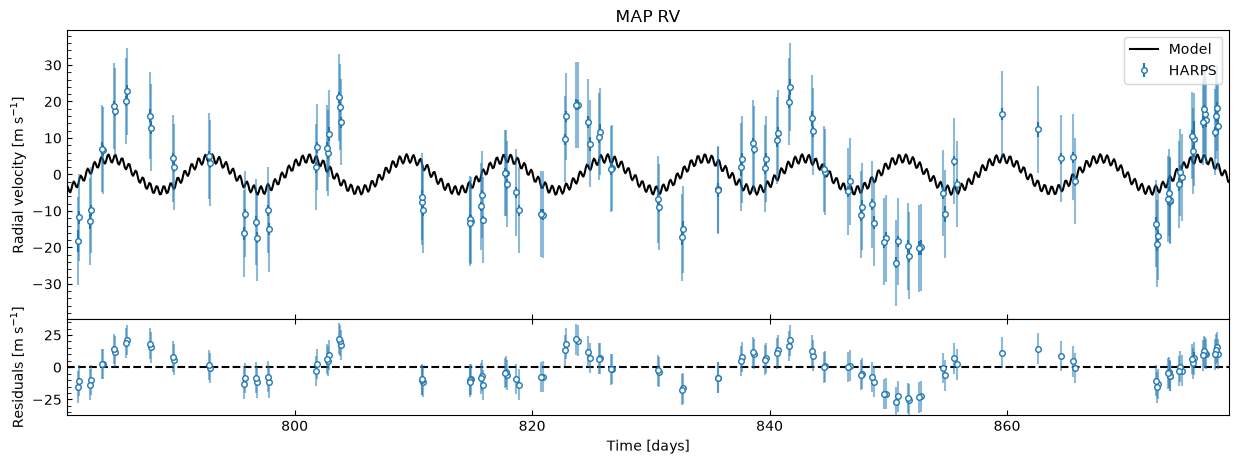

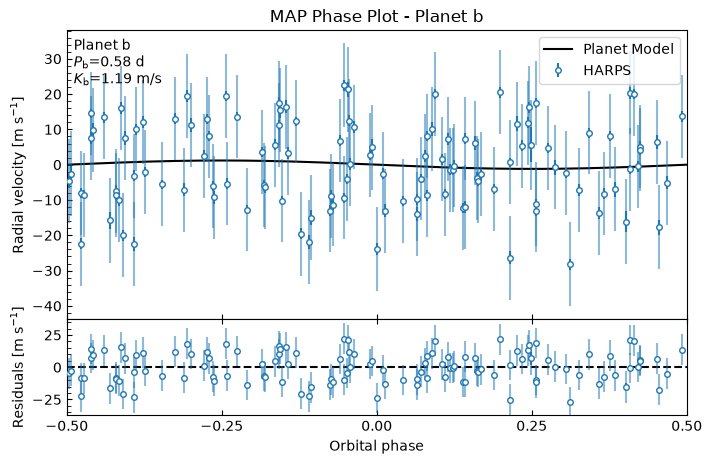

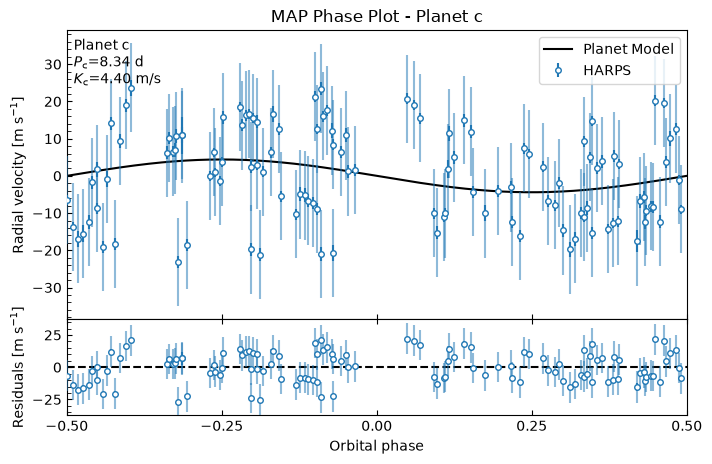

In [ ]:
fitter.plot_MAP_rv(map_result=map_results)
fitter.plot_MAP_phase(planet_letter="b", map_result=map_results)
fitter.plot_MAP_phase(planet_letter="c", map_result=map_results)

This is a terrible fit! We have constraints on $P$ and $T_\text{C}$ for both planets from the priors, but even then we can see the system RV still has a correlated pattern in the residuals. This is normally a sign there's either another potential planet, or there's strong periodic stellar activity that you'll want to use a GP to mitigate. Furthermore, on the phase plots, the residual spread is larger than the semi-amplitude of the planet! If we didn't a priori know there were planets here from transit photometry, then this wouldn't be a planetary detection at all.

### The main MCMC fit

Let's proceed with MCMC. To speed things up for this notebook, we'll use the minimum number of walkers (twice the number of free parameters) and we'll initialise the walkers in a small ball around the MAP values. You'll definitely want to use more than this (at least one hundred). You could also try initialising the walkers randomly within the full parameter- and prior-space with `fitter.generate_initial_walker_positions_random()`.

In [ ]:
nwalkers = 2 * fitter.ndim
mcmc_init = fitter.generate_initial_walker_positions_around_point(centre=map_results.x, nwalkers=nwalkers, verbose=False)

We'll enable convergence checking: at given intervals through the MCMC, it checks if two criteria are met: first, that the chains are more than 50 times longer than the estimated autocorrelation time for that parameter. Secondly, it checks that the estimate for autocorrelation time is stable (that it hasn't deviated by more than 1%). This is because the estimate becomes more accurate as you run for longer, so if you don't check for this you could accidentally stop the MCMC early.

In [ ]:
max_steps = 30_000
fitter.run_mcmc(initial_positions=mcmc_init, nwalkers=nwalkers, max_steps=max_steps, progress=True,
                multiprocessing=True,
                check_convergence=True, convergence_check_interval=1000, convergence_check_start=15000
                )  # This will take a few minutes!

INFO:root:Starting MCMC with convergence checks. (Maximum 30000 steps, checking convergence every 1000 steps after iteration 15000)...
 50%|████▉     | 14929/30000 [00:16<00:16, 937.92it/s]INFO:root:Convergence check: Step 15000: mean(tau)=104.0, max(tau)=124.4
INFO:root:Not yet converged (N/50>tau check: True, tau stability check: False)
 53%|█████▎    | 15938/30000 [00:17<00:16, 869.95it/s]INFO:root:Convergence check: Step 16000: mean(tau)=104.8, max(tau)=126.3
INFO:root:Not yet converged (N/50>tau check: True, tau stability check: False)
 57%|█████▋    | 16999/30000 [00:18<00:13, 955.37it/s]INFO:root:Convergence check: Step 17000: mean(tau)=106.3, max(tau)=129.8
INFO:root:Not yet converged (N/50>tau check: True, tau stability check: False)
 60%|█████▉    | 17960/30000 [00:20<00:13, 895.67it/s]INFO:root:Convergence check: Step 18000: mean(tau)=106.6, max(tau)=129.0
INFO:root:Not yet converged (N/50>tau check: True, tau stability check: False)
 63%|██████▎   | 18916/30000 [00:21<00:12

### Getting the MCMC samples

Let's take the last 10,000 samples and thin by 10, so that we have 1,000 samples per walker.

In [ ]:
nburn = fitter.sampler.iteration - 10_000
thin_rate = 10

# Get the samples as a numpy array
samples = fitter.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate, flat=False) # shape (nsteps, nwalkers, ndim)

### MCMC diagnostics

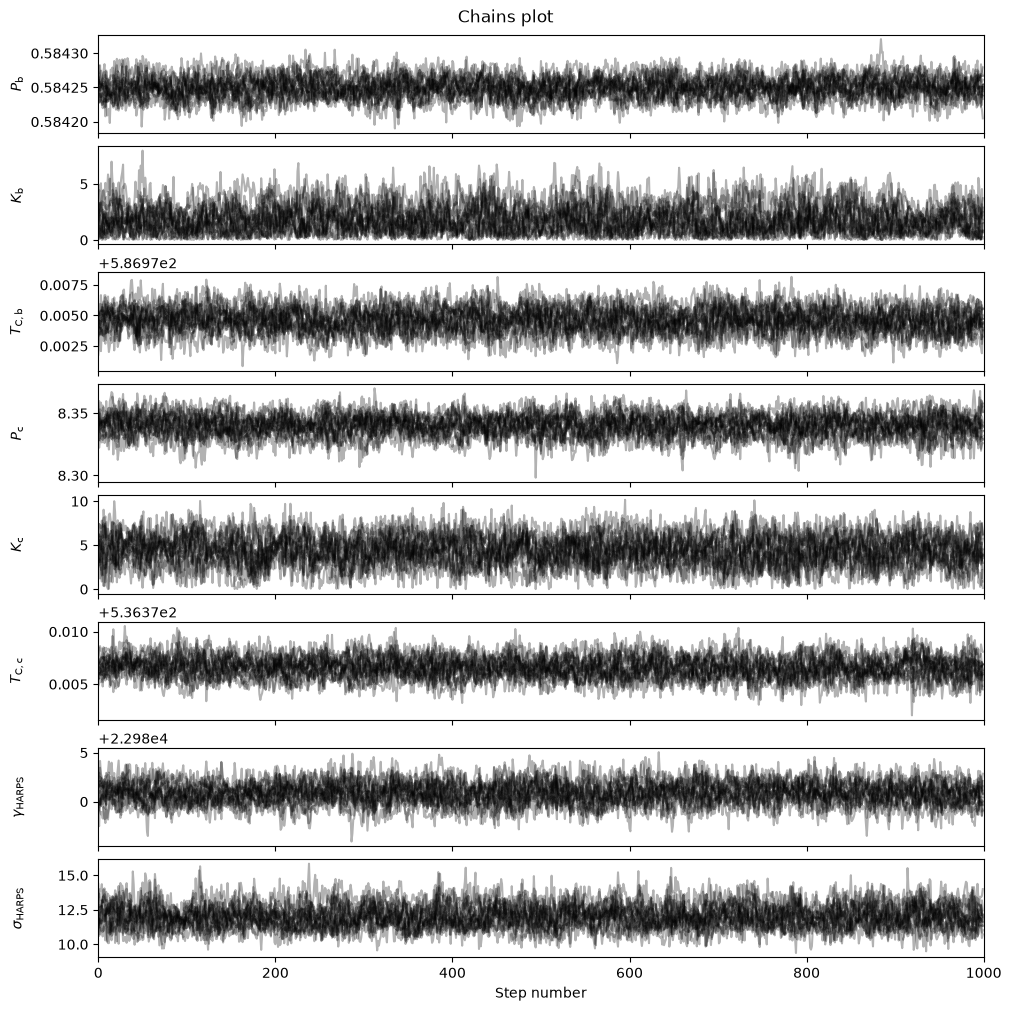

In [ ]:
fitter.plot_chains(discard_start=nburn, discard_end=0, thin=thin_rate, save=False)

### Results

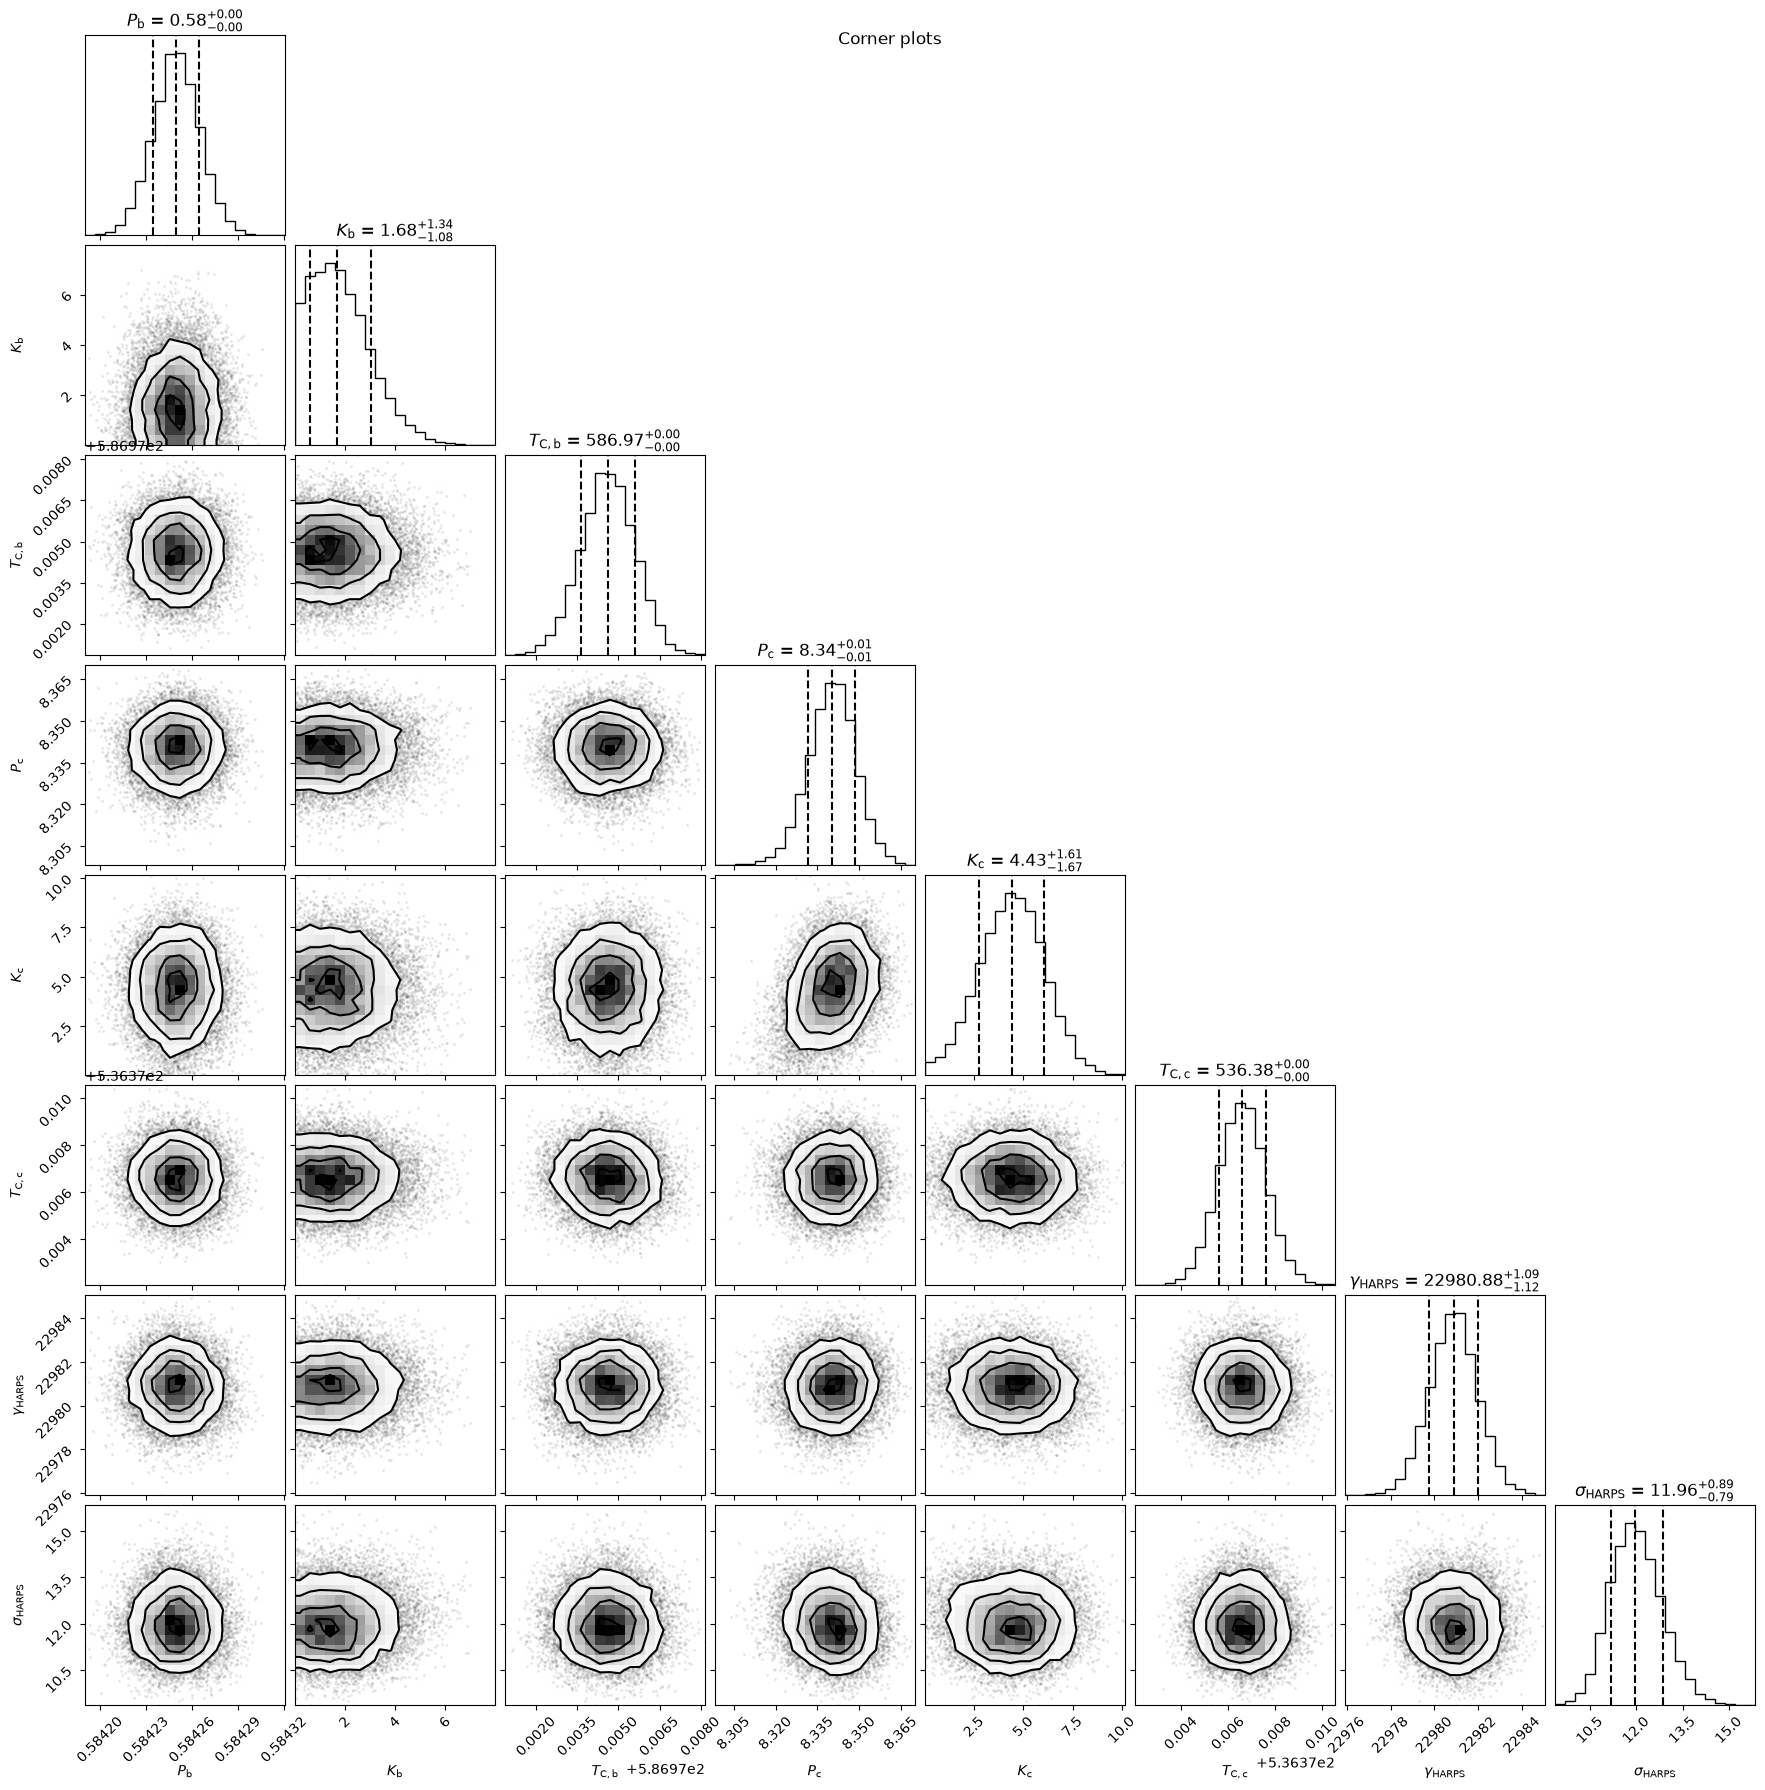

In [ ]:
fitter.plot_corner(discard_start=nburn, discard_end=0, thin=thin_rate, plot_datapoints=True, save=False)

#### Posterior RV and phase plots

The parameter distributions shown in the chains and corner plots look well-behaved (converged, more-or-less Normal distributions), but this is misleading - recall that the actual fit to the data (after the MAP optimisation) was poor. We can plot the posterior RV and phase plots using our MCMC samples to check this:

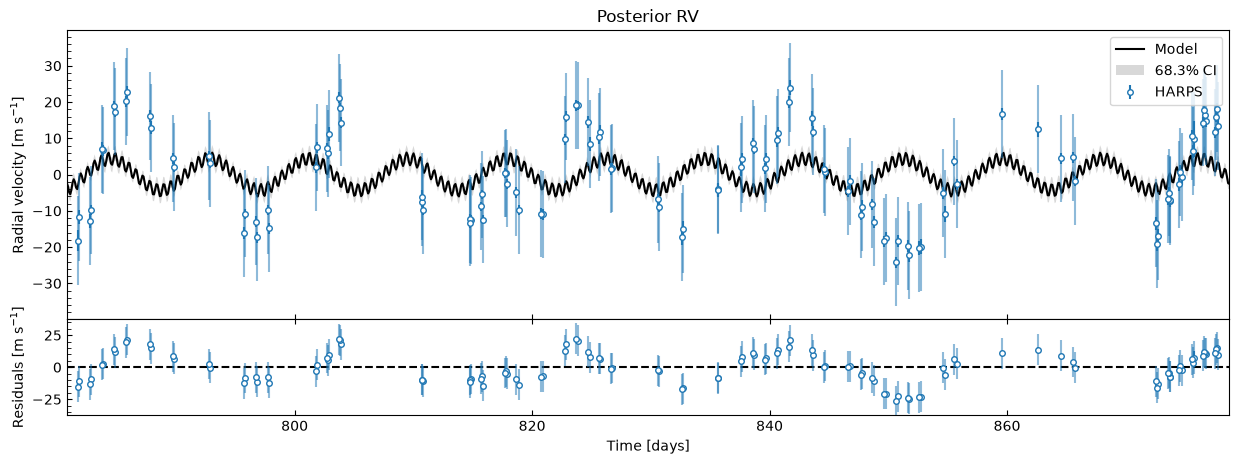

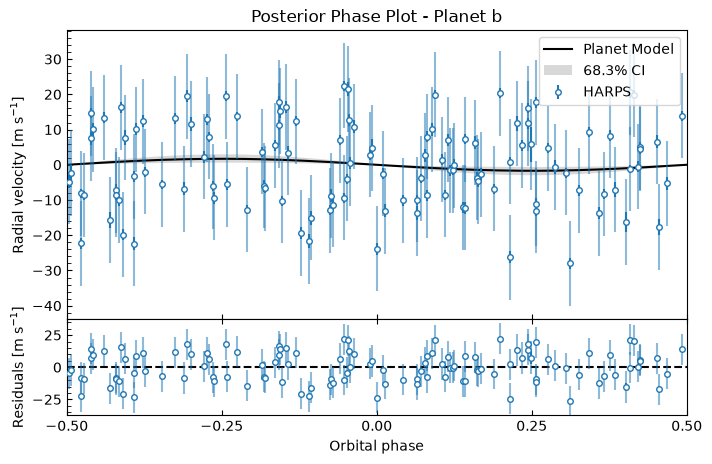

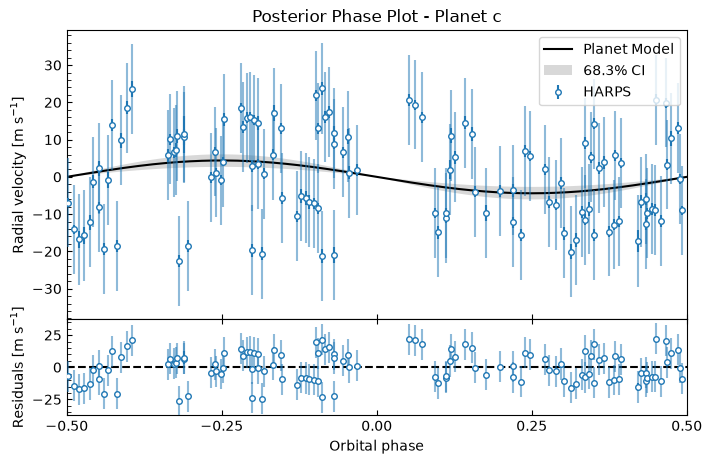

In [ ]:
# Use more aggressive thinning for RV/phase plots as they're computationally expensive
plot_thin = thin_rate * 10

fitter.plot_posterior_rv(discard_start=nburn, discard_end=0, thin=plot_thin)
fitter.plot_posterior_phase("b", discard_start=nburn, discard_end=0, thin=plot_thin)
fitter.plot_posterior_phase("c", discard_start=nburn, discard_end=0, thin=plot_thin)

Again, it's a terrible fit! This confirms that it wasn't just that the MAP failed to reach a good solution (which can happen), it shows that even across the posterior MCMC samples, the fit is consistently terrible, suggesting this white-noise model isn't suitable here. The correlated residuals indicate we should use a GP to model stellar activity.

### Goodness of fit and information criteria

We can quickly look at the final parameter values for each parameter's marginalised posterior distribution (say, the 50th percentile/median of each parameter's flattened chains) and compute some quick summary statistics of our fit so we can compare it with the GP fit later.

In [ ]:
# For the non-GP Fitter
print("Results for Fitter (white noise model)")

# Get flattened samples (with the same discard and thinning)
fitter_samples = fitter.get_samples_np(discard_start=nburn, discard_end=0, thin=10, flat=True)

# Calculate 50th percentile for each free parameter
fitter_medians = np.percentile(fitter_samples, 50, axis=0)
print(f"\nMedian free parameter values:")
for name, value in zip(fitter.free_params_names, fitter_medians):
    print(f"  {name}: {value}")

Results for Fitter (white noise model)

Median free parameter values:
  P_b: 0.5842496702376774
  K_b: 1.6823846984856954
  Tc_b: 586.9746109518132
  P_c: 8.340430800461462
  K_c: 4.426220068371023
  Tc_c: 536.376579615377
  g_HARPS: 22980.88139654234
  jit_HARPS: 11.964955987803688


In [ ]:
# Build complete params dict (combines free params with fixed params)
fitter_complete_dict = fitter.build_params_dict(fitter_medians)
fitter_complete_dict

{'e_b': 0,
 'w_b': 1.5707963267948966,
 'e_c': 0,
 'w_c': 1.5707963267948966,
 'gd': 0,
 'gdd': 0,
 'P_b': np.float64(0.5842496702376774),
 'K_b': np.float64(1.6823846984856954),
 'Tc_b': np.float64(586.9746109518132),
 'P_c': np.float64(8.340430800461462),
 'K_c': np.float64(4.426220068371023),
 'Tc_c': np.float64(536.376579615377),
 'g_HARPS': np.float64(22980.88139654234),
 'jit_HARPS': np.float64(11.964955987803688)}

We can calculate a few metrics for the white-noise model to see how (badly) it has performed:

In [ ]:
# Calculate metrics
fitter_chi2 = fitter.calculate_chi2(fitter_complete_dict)
fitter_loglike = fitter.calculate_log_likelihood(fitter_complete_dict)
fitter_aicc = fitter.calculate_aicc(fitter_complete_dict)  # corrected Akaike Information Criterion
fitter_bic = fitter.calculate_bic(fitter_complete_dict)  # Bayesian Information Criterion

print(f"Metrics at 50th percentile:")
print(f"Chi^2:          {fitter_chi2:.2f}")
print(f"Log-likelihood: {fitter_loglike:.2f}")
print(f"AICc:           {fitter_aicc:.2f}")
print(f"BIC:            {fitter_bic:.2f}")

Metrics at 50th percentile:
Chi^2:          116.10
Log-likelihood: -467.38
AICc:           952.05
BIC:            973.06


---

## Fitting with a Gaussian Process

I'm assuming some familiarity with Gaussian Processes here; if not then I recommend the excellent review article [Aigrain & Foreman-Mackey 2023](https://ui.adsabs.harvard.edu/abs/2023ARA%26A..61..329A/abstract) as a starting point.

To use a GP in Ravest, we use the `GPFitter` class. The interface to this is very similar to the `Fitter` class we just used, but with an extra step to set up the GP kernel, whose hyperparameters are then fitted alongside the planetary parameters.

In [ ]:
from ravest.fit import GPFitter
from ravest.gp import GPKernel

### The GP kernel

We will use the Quasiperiodic Kernel as defined by [Roberts et al. 2013](https://ui.adsabs.harvard.edu/abs/2013RSPTA.37110550R/abstract) (with slightly different notation):  
  
$$ k_\text{QP} (t_i,t_j) = A_\text{GP}^2 \exp \left\{ - \frac{\sin^2\left[ \pi \left( t_i - t_j \right) / P_\text{GP}\right]}{2\lambda^2_\text{p}}   - \frac{\left( t_i - t_j \right) ^2}{2\lambda^2_\text{e}} \right\} $$
  
where $A_\text{GP}$ is the GP amplitude, $P_\text{GP}$ and $\lambda_\text{p}$ are the period and length scale of the periodic component, and $\lambda_\text{e}$ is the evolutionary timescale. 

In [ ]:
gpkernel = GPKernel(kernel_type="Quasiperiodic")
gpkernel.param_names

['gp_amp', 'gp_lambda_e', 'gp_lambda_p', 'gp_period']

### Set up the `GPFitter`

In [ ]:
parameterisation=Parameterisation("P K e w Tc")
gpfitter = GPFitter(planet_letters=["b","c"], parameterisation=parameterisation, 
                    gp_kernel=gpkernel)
gpfitter.add_data(
                time=(data["BJD"].to_numpy()-2457000), 
                vel=data["RV"].to_numpy(),
                velerr=data["e_RV"].to_numpy(),
                instrument=data["tel"].to_numpy(),
                t0=np.mean(data["BJD"].to_numpy()-2457000),
)

For the planetary/system parameters, we'll use the same `params` and `priors` as before. A `GPFitter` also stores the GP kernel's hyperparameters and hyperpriors in the same `params` and `priors` dicts though, so we'll need to choose the new hyperparameter and hyperprior values first, and then set everything together.

### Hyperparameters and hyperpriors

Now we need to choose the hyperparameters and their hyperpriors for the GP kernel. Again in the interests of making this converge quickly so the notebook runs quickly, we adopt the published values from Santerne et al. 2018 for the hyperparameters.

In [ ]:
hyperparams = {
    "gp_A": Parameter(value=12.3, fixed=False),
    "gp_lambda_e": Parameter(value=16.7, fixed=False),
    "gp_lambda_p": Parameter(value=0.71, fixed=False),
    "gp_P": Parameter(value=18.2, fixed=False),
}

gpfitter.params = params | hyperparams
gpfitter.params

{'gp_amp': Parameter(value=12.3, unit='', fixed=False),
 'gp_lambda_e': Parameter(value=16.7, unit='d', fixed=False),
 'gp_lambda_p': Parameter(value=0.71, unit='', fixed=False),
 'gp_period': Parameter(value=18.2, unit='d', fixed=False)}

In [ ]:
# Hyperpriors from Santerne et al. 2018 Nature paper supplementary table 6
hyperpriors = {
        "gp_A": ravest.prior.Uniform(0, 100),
        "gp_lambda_e": ravest.prior.Normal(16.7, 2.5),
        "gp_lambda_p": ravest.prior.Normal(0.71, 0.12),
        "gp_P": ravest.prior.Normal(18.2, 0.3),
}

gpfitter.priors = priors | hyperpriors
gpfitter.priors

{'gp_amp': Uniform(lower=0, upper=100),
 'gp_lambda_e': Normal(mean=16.7, std=2.5),
 'gp_lambda_p': Normal(mean=0.71, std=0.12),
 'gp_period': Normal(mean=18.2, std=0.3)}

### The initial MAP fit

In [ ]:
gpmap_results = gpfitter.find_map_estimate(method="Powell")
gpmap_results

INFO:2026-09-28 02:31:36,316:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


MAP parameter results: {'P_b': np.float64(0.584251046306648), 'K_b': np.float64(2.1373362338691875), 'Tc_b': np.float64(586.9746150639935), 'P_c': np.float64(8.328416186497165), 'K_c': np.float64(2.5761957951852112), 'Tc_c': np.float64(536.3766003054924), 'g_HARPS': np.float64(22980.809820676455), 'jit_HARPS': np.float64(1.6778678008359222)}
MAP hyperparameter results: {'gp_amp': np.float64(12.294560626739061), 'gp_lambda_e': np.float64(17.202054422711484), 'gp_lambda_p': np.float64(0.4177700643796267), 'gp_period': np.float64(18.3952023210213)}


 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 338.25218426705675
       x: [ 5.843e-01  2.137e+00  5.870e+02  8.328e+00  2.576e+00
            5.364e+02  2.298e+04  1.678e+00  1.229e+01  1.720e+01
            4.178e-01  1.840e+01]
     nit: 5
   direc: [[ 1.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ...  1.000e+00  0.000e+00]
           [-2.202e-07  2.455e-02 ... -4.034e-02 -2.622e-02]]
    nfev: 620

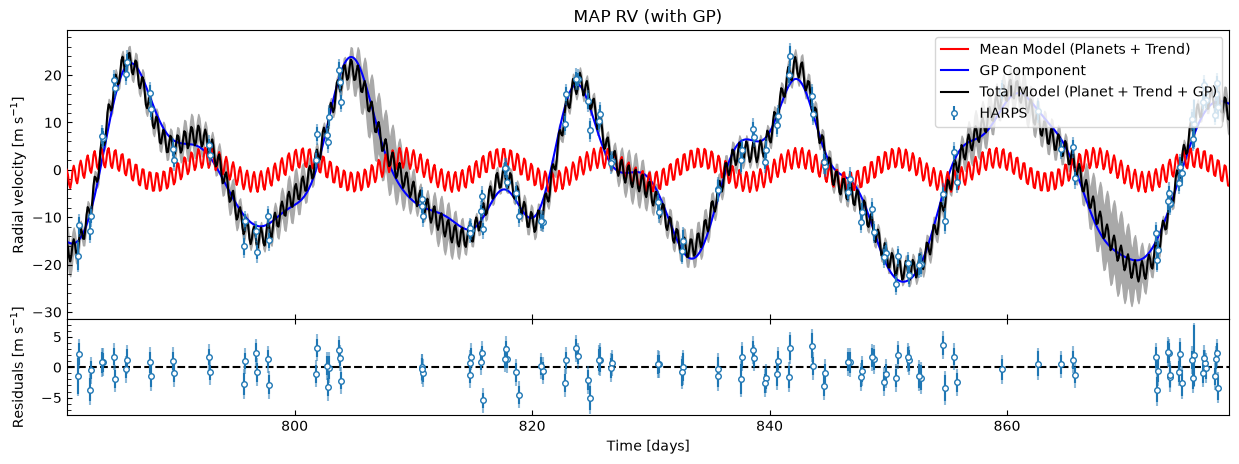

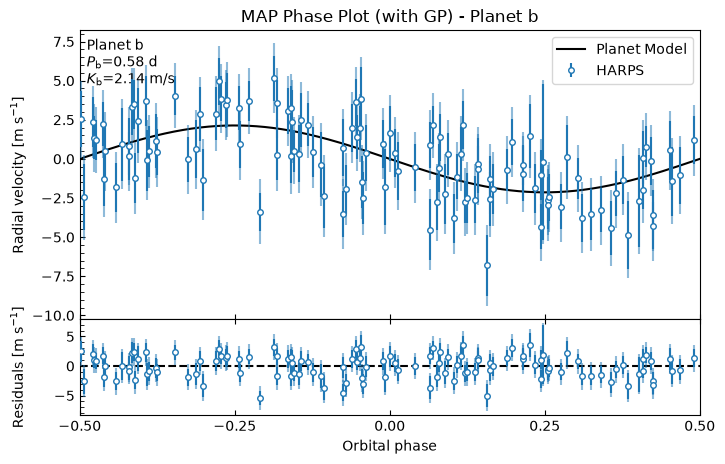

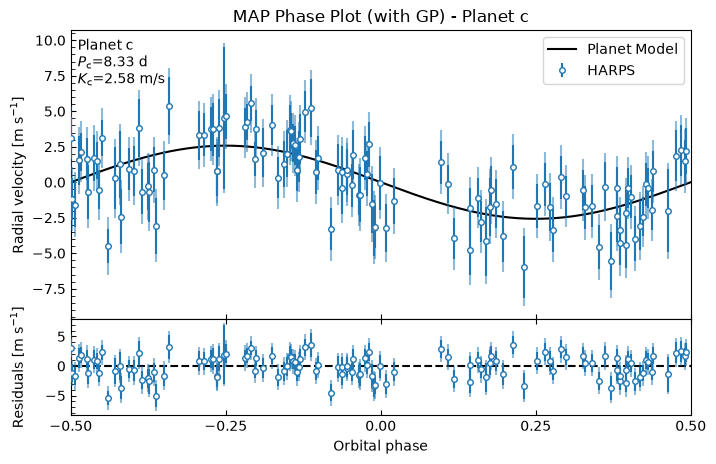

In [ ]:
gpfitter.plot_MAP_rv(map_result=gpmap_results)
gpfitter.plot_MAP_phase(planet_letter="b", map_result=gpmap_results)
gpfitter.plot_MAP_phase(planet_letter="c", map_result=gpmap_results)

This looks a lot better! The GP has fitted to the correlated noise well. The system RV residuals no longer look correlated (it now looks like white noise), and the planetary phase plots look much better.

### The main MCMC fit

Let's start MCMC. Again we will run this for the minimum number of walkers (two times the number of free parameters) initialised in a ball around the MAP results, and only run for a small number of steps so that this notebook runs quickly. You should definitely use more walkers and steps!

In [ ]:
nwalkers = 2 * gpfitter.ndim
mcmc_init = gpfitter.generate_initial_walker_positions_around_point(centre=gpmap_results.x, nwalkers=nwalkers, verbose=False)

In [ ]:
# Fit the free parameters to the data. Use the MAP solution as the initial value for the MCMC walkers.
gpfitter.run_mcmc(initial_positions=mcmc_init,
                  nwalkers=nwalkers, max_steps=20_000, progress=True,
                  multiprocessing=True,
                  check_convergence=True, convergence_check_interval=1000, convergence_check_start=15000
                  )  # This will take a few minutes!

INFO:root:Starting MCMC with convergence checks. (Maximum 20000 steps, checking convergence every 1000 steps after iteration 15000)...
INFO:2026-09-28 02:31:41,843:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:2026-09-28 02:31:41,966:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/O

### Convergence

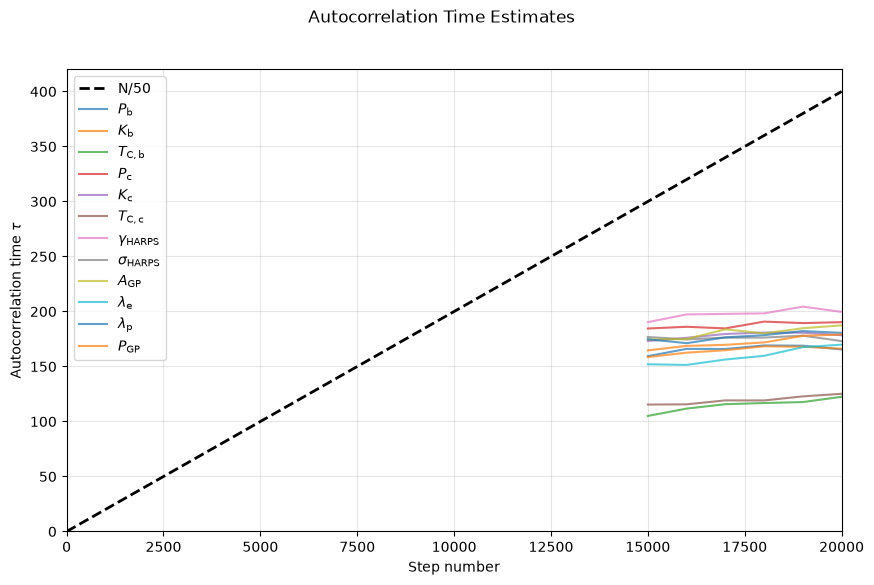

In [ ]:
gpfitter.plot_autocorr_estimates()

Looking at the autocorrelation estimate plot, we can consider these chains converged as the chains are all considerably longer than 50 times the estimated autocorrelation time (below the dashed line), and the estimates look stable (even if they didn't quite meet the formal $\Delta{\tau}<1$% stability criterion).

### Getting the MCMC samples

Again we'll take the last 10,000 iterations and thin by 10, to have 1,000 samples per walker.

In [ ]:
nburn = gpfitter.sampler.iteration - 10_000

# Get the samples as a numpy array
gpsamples = gpfitter.get_samples_np(discard_start=nburn, discard_end=0, thin=thin_rate, flat=False) # shape (nsteps, nwalkers, ndim)

# Get the samples as a labelled Pandas dataframe
gpsamples_df = gpfitter.get_samples_df(discard_start=nburn, discard_end=0, thin=10)  # shape (nsteps*nwalkers, ndim)
gpsamples_df

,P_b,K_b,Tc_b,P_c,K_c,Tc_c,g_HARPS,jit_HARPS,gp_amp,gp_lambda_e,gp_lambda_p,gp_period
0,0.584255,2.527415,586.974178,8.327167,5.114814,536.375648,22983.388033,1.639965,18.098750,18.411810,0.555492,18.018018
1,0.584251,1.914839,586.975284,8.333577,4.205163,536.377415,22976.657659,1.690554,15.914980,18.367343,0.475101,18.257420
2,0.584259,2.504553,586.975454,8.303575,4.710963,536.378395,22982.591924,1.811447,15.057288,16.282717,0.535817,18.381827
3,0.584231,2.101776,586.974465,8.336432,2.966103,536.376507,22971.756855,1.668973,14.820849,17.114105,0.493949,18.258999
4,0.584240,2.631357,586.974087,8.333489,2.573188,536.377337,22985.007088,1.976657,9.773798,15.743173,0.422643,18.609350
...,...,...,...,...,...,...,...,...,...,...,...,...
23995,0.584245,2.483222,586.973835,8.320344,0.321119,536.377238,22985.227312,1.555749,14.484466,18.483868,0.457847,18.677184
23996,0.584249,2.692445,586.974133,8.327132,3.727439,536.377390,22966.404967,1.841219,18.425625,17.851187,0.554027,18.378686
23997,0.584274,2.095801,586.975054,8.329698,3.664093,536.377031,22979.519671,1.397933,16.527795,16.182323,0.460522,18.557703
23998,0.584256,2.940562,586.974577,8.327398,3.133832,536.377143,22983.880794,1.976656,18.183569,19.551983,0.550045,18.389957


### MCMC diagnostics

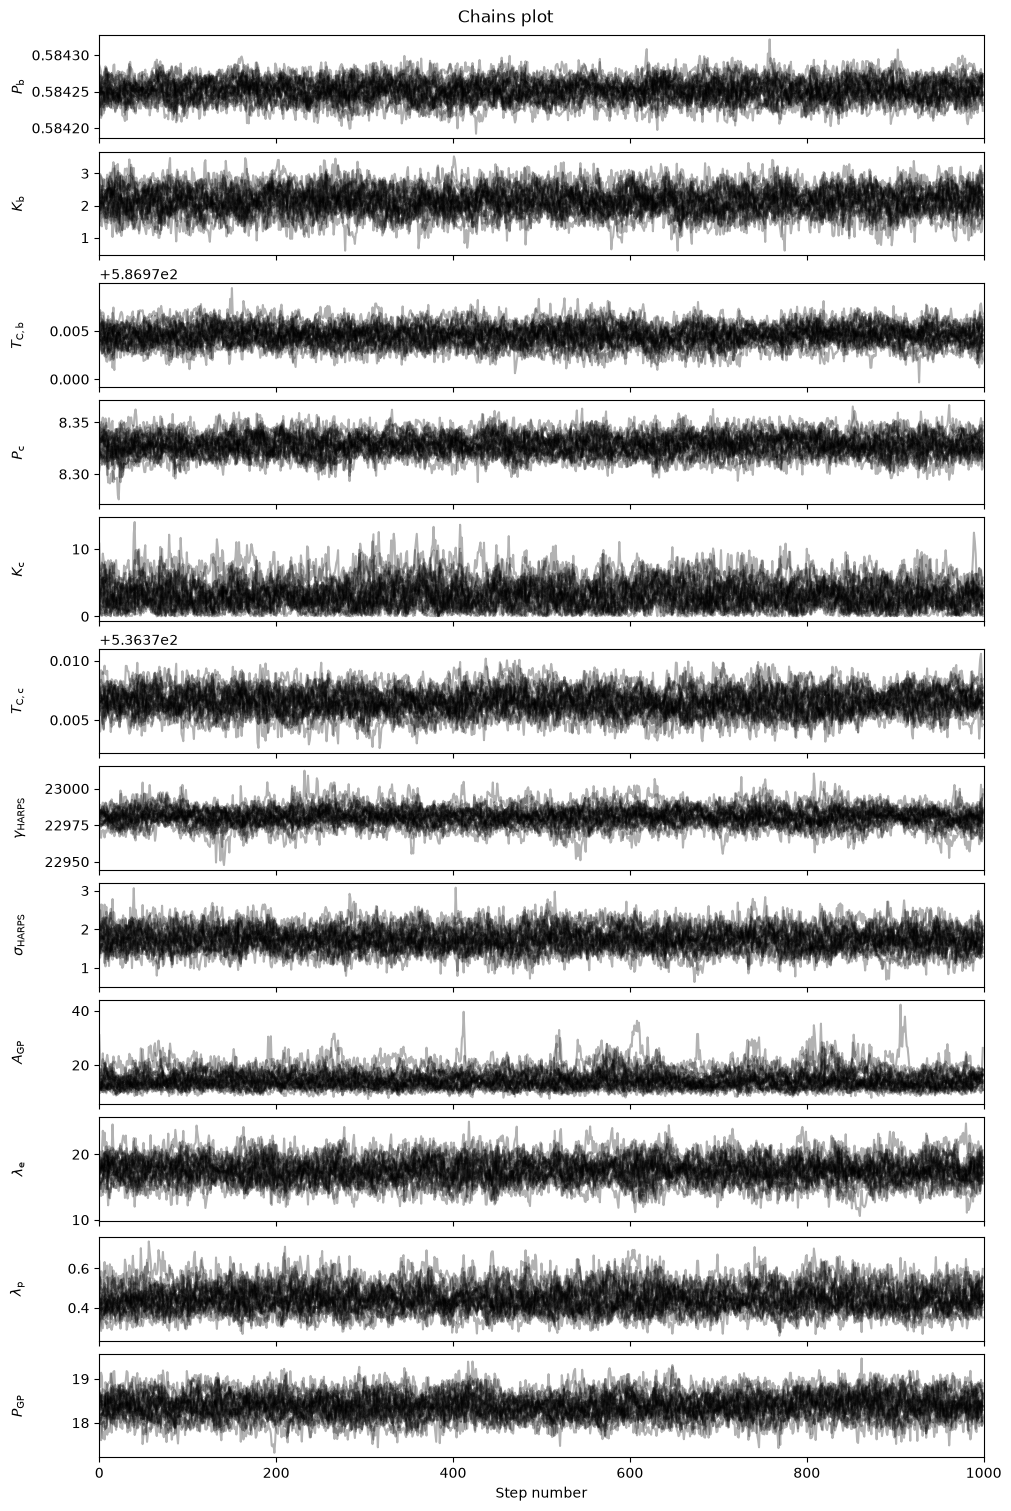

In [ ]:
gpfitter.plot_chains(discard_start=nburn, discard_end=0, thin=thin_rate, save=False)

### Results

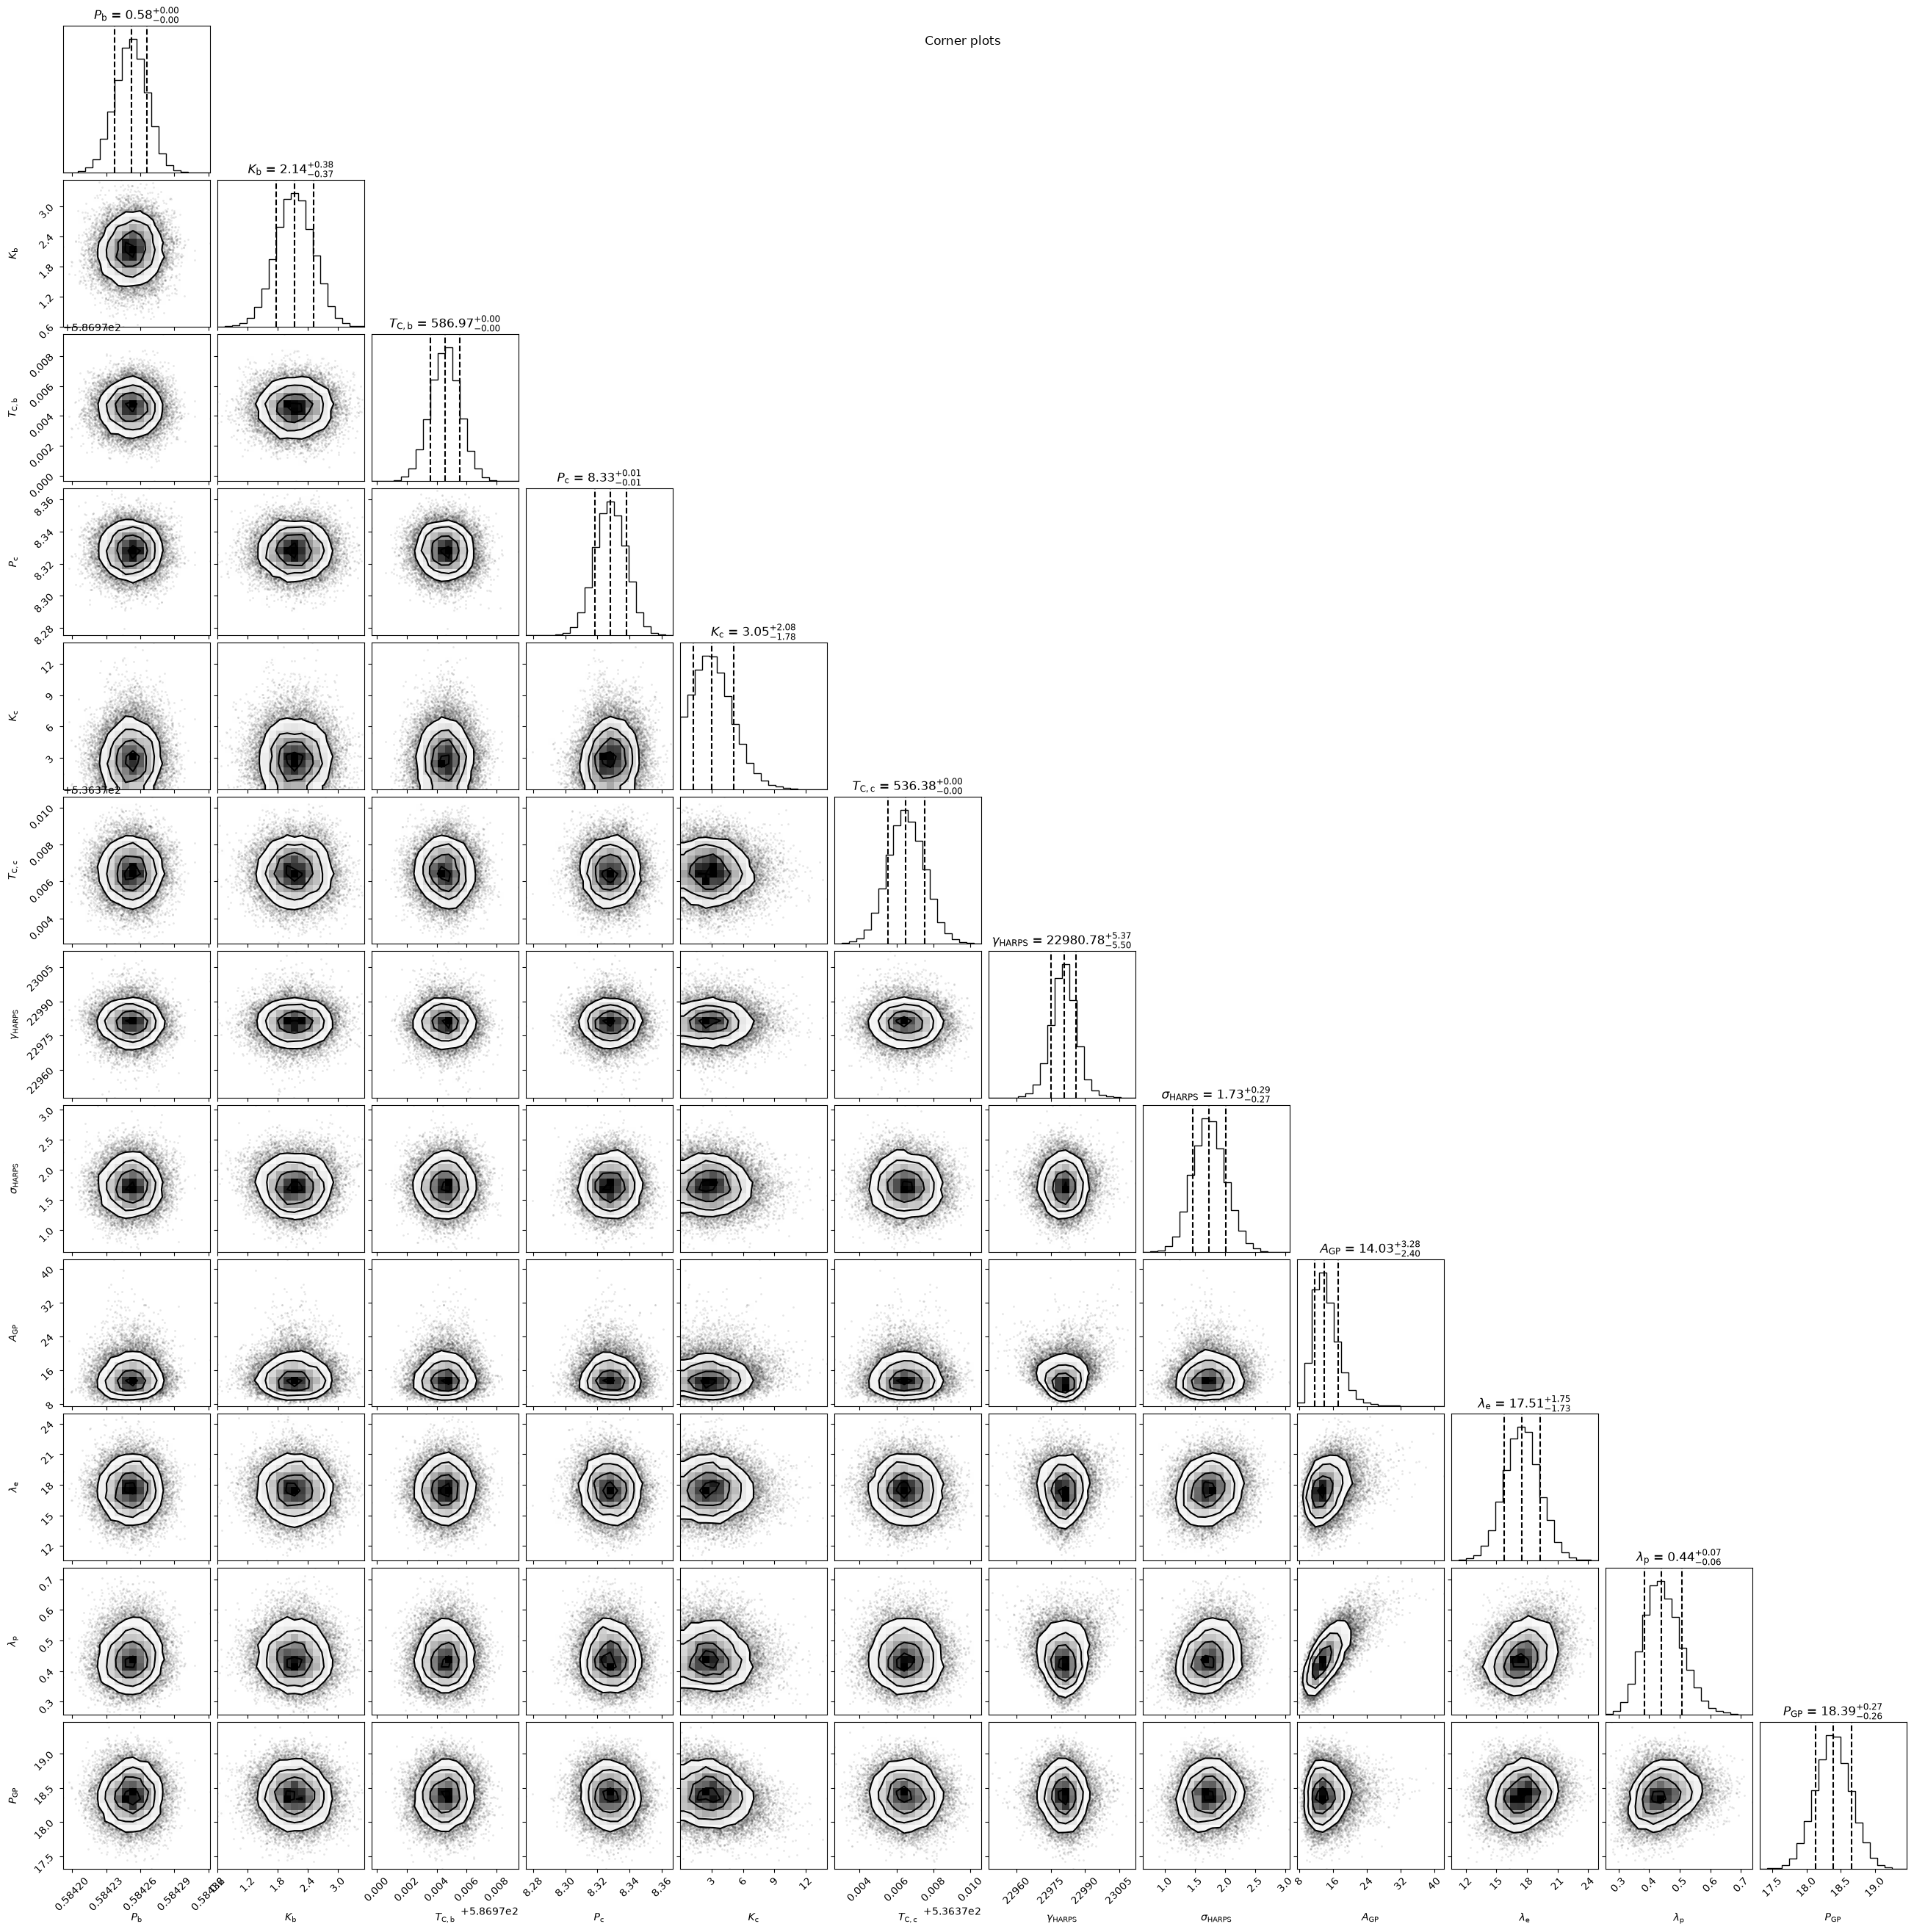

In [ ]:
gpfitter.plot_corner(discard_start=nburn, discard_end=0, thin=thin_rate, plot_datapoints=True, save=False,)

Chains and corners look good (unsurprising given the tight priors we imposed!) It's not uncommon for GP hyperparameters to be multi-modal; if you encounter this then you may want to reconsider your choices of priors.

#### Posterior RV and phase plots

Let's look at the posterior RV and phase plots, with the GP's 1-$\sigma$ uncertainty plotted too. Again we 10x the thin rate here because these plots can take a while due to all the GP evaluations required from each sample.

Processing 2400 effective samples (after discard_start=10000, discard_end=0, thin=100)
Calculating planet b RV at 120 observed times...


Calculating planet b RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 83934.34it/s]


Calculating planet b RV at 1000 smooth times...


Calculating planet b RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 39904.26it/s]


Calculating planet c RV at 120 observed times...


...

Calculating planet c RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 64122.88it/s]


Calculating trend RV at 120 observed times...


Calculating trend RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 122205.72it/s]


Calculating trend RV at 1000 smooth times...


Computing GP predictions: 100%|██████████| 2400/2400 [01:04<00:00, 36.97it/s]


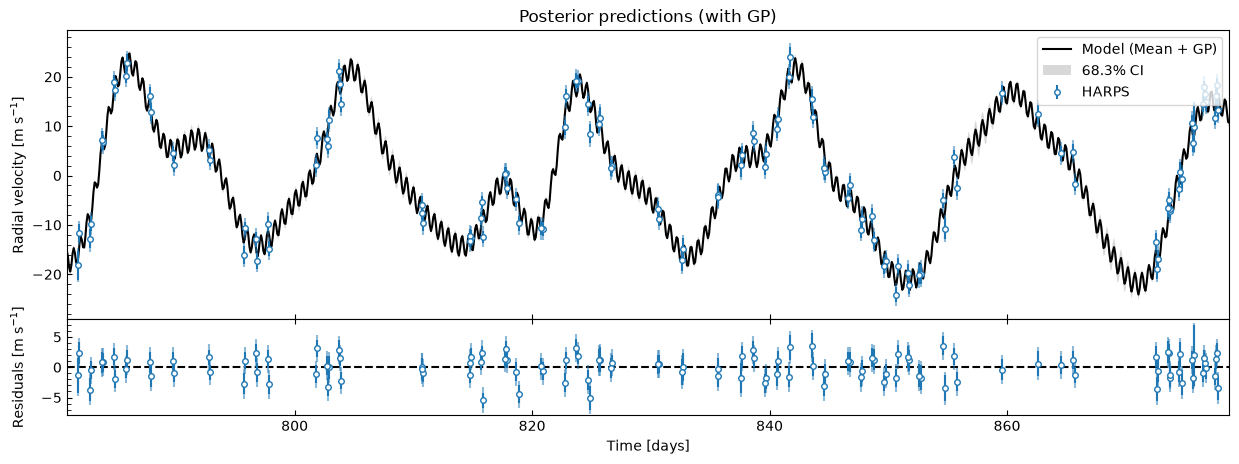

In [ ]:
# Use more aggressive thinning for RV/phase plots
plot_thin = thin_rate * 10

gpfitter.plot_posterior_rv(discard_start=nburn, discard_end=0, thin=plot_thin)

Processing 2400 effective samples (after discard_start=10000, discard_end=0, thin=100)
Calculating planet b RV at 120 observed times...


Calculating planet b RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 55441.41it/s]


Calculating planet b RV at 500 smooth times...


Calculating planet b RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 66170.13it/s]


Calculating planet c RV at 120 observed times...


Calculating planet c RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 78936.75it/s]


Calculating trend RV at 120 observed times...


100%|██████████| 2400/2400 [00:27<00:00, 86.58it/s]


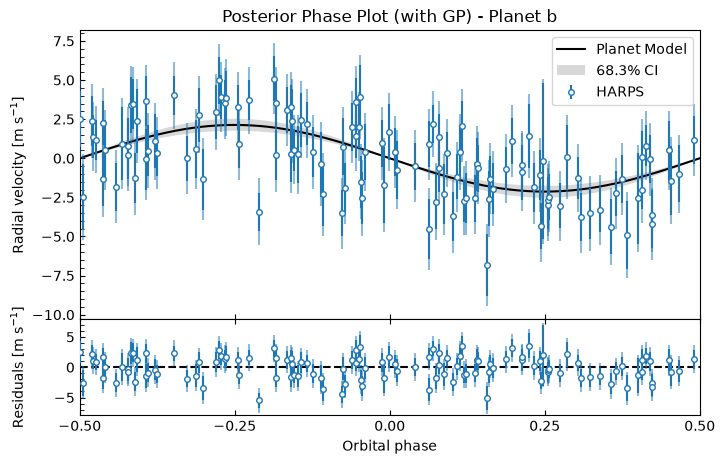

In [ ]:
gpfitter.plot_posterior_phase("b", discard_start=nburn, discard_end=0, thin=plot_thin)

Processing 2400 effective samples (after discard_start=10000, discard_end=0, thin=100)
Calculating planet c RV at 120 observed times...


Calculating planet c RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 86123.13it/s]


Calculating planet c RV at 500 smooth times...


Calculating planet c RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 79106.72it/s]


Calculating planet b RV at 120 observed times...


Calculating planet b RV from samples: 100%|██████████| 2400/2400 [00:00<00:00, 87556.14it/s]


Calculating trend RV at 120 observed times...


100%|██████████| 2400/2400 [00:27<00:00, 87.70it/s]


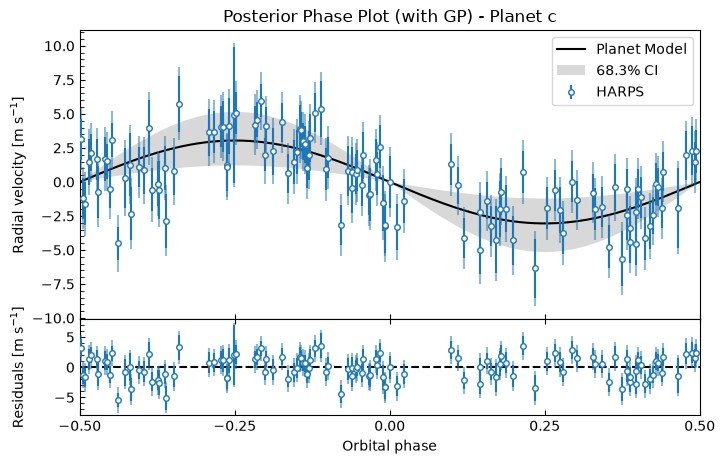

In [ ]:
gpfitter.plot_posterior_phase("c", discard_start=nburn, discard_end=0, thin=plot_thin)

### Goodness of fit and information criteria

In [ ]:
# For the GPFitter
print("Results for GPFitter (with Gaussian Process)")

# Get flattened samples (discard burn-in)
gpfitter_samples = gpfitter.get_samples_np(discard_start=nburn, discard_end=0, thin=1, flat=True)

# Calculate 50th percentile for each free parameter (GP hyperparameters included)
gpfitter_medians = np.percentile(gpfitter_samples, 50, axis=0)
print(f"\nMedian free parameter values:")
for name, value in zip(gpfitter.free_params_names, gpfitter_medians):
    print(f"  {name}: {value}")

Results for GPFitter (with Gaussian Process)

Median free parameter/hyperparameter values:
  P_b: 0.5842521004335678
  K_b: 2.1383627795136193
  Tc_b: 586.9745668542147
  P_c: 8.328113515567097
  K_c: 3.0390627191167043
  Tc_c: 536.376512702868
  g_HARPS: 22980.786268630734
  jit_HARPS: 1.732335235113553
  gp_amp: 14.027118257630704
  gp_lambda_e: 17.513507016422768
  gp_lambda_p: 0.44112727405978897
  gp_period: 18.38836101488895


In [ ]:
# Build complete params dict (combines free params with fixed params, GP hyperparameters included)
gpfitter_complete_dict = gpfitter.build_params_dict(gpfitter_medians)
gpfitter_complete_dict

{'e_b': 0,
 'w_b': 1.5707963267948966,
 'e_c': 0,
 'w_c': 1.5707963267948966,
 'gd': 0,
 'gdd': 0,
 'P_b': np.float64(0.5842521004335678),
 'K_b': np.float64(2.1383627795136193),
 'Tc_b': np.float64(586.9745668542147),
 'P_c': np.float64(8.328113515567097),
 'K_c': np.float64(3.0390627191167043),
 'Tc_c': np.float64(536.376512702868),
 'g_HARPS': np.float64(22980.786268630734),
 'jit_HARPS': np.float64(1.732335235113553),
 'gp_amp': np.float64(14.027118257630704),
 'gp_lambda_e': np.float64(17.513507016422768),
 'gp_lambda_p': np.float64(0.44112727405978897),
 'gp_period': np.float64(18.38836101488895)}

We can calculate the same performance metrics that we did earlier for the white-noise model:

In [ ]:
# Calculate metrics
gpfitter_chi2 = gpfitter.calculate_chi2(gpfitter_complete_dict)
gpfitter_loglike = gpfitter.calculate_log_likelihood(gpfitter_complete_dict)
gpfitter_aicc = gpfitter.calculate_aicc(gpfitter_complete_dict)  # corrected Akaike Information Criterion
gpfitter_bic = gpfitter.calculate_bic(gpfitter_complete_dict)  # Bayesian Information Criterion

print(f"\nMetrics at 50th percentile:")
print(f"  Chi^2:          {gpfitter_chi2:.2f}")
print(f"  Log-likelihood: {gpfitter_loglike:.2f}")
print(f"  AICc:            {gpfitter_aicc:.2f}")
print(f"  BIC:            {gpfitter_bic:.2f}")


Metrics at 50th percentile:
  Chi^2:          110.99
  Log-likelihood: -338.30
  AICc:            703.51
  BIC:            734.04


---

## Model comparison

Now let's compare the two models quantitatively using the metrics we've calculated. While visual inspection of the residuals clearly shows the GP model fits better, we can use statistical metrics to quantify this improvement.

In [ ]:
print(f"\n{'Metric':<20} {'No GP':>12} {'GP':>12}   {'':>20}")
print("-" * 70)
print(f"{'Free parameters':<20} {fitter.ndim:>12} {gpfitter.ndim:>12}")
print(f"{'Chi2':<20} {fitter_chi2:>12.2f} {gpfitter_chi2:>12.2f}   {'(lower is better)':>20}")
print(f"{'Log-likelihood':<20} {fitter_loglike:>12.2f} {gpfitter_loglike:>12.2f}   {'(higher is better)':>20}")
print(f"{'AICc':<20} {fitter_aicc:>12.2f} {gpfitter_aicc:>12.2f}   {'(lower is better)':>20}")
print(f"{'BIC':<20} {fitter_bic:>12.2f} {gpfitter_bic:>12.2f}   {'(lower is better)':>20}")


Metric                      No GP           GP                       
----------------------------------------------------------------------
Free parameters                 8           12
Chi2                       116.10       110.99      (lower is better)
Log-likelihood            -467.38      -338.30     (higher is better)
AICc                       952.05       703.51      (lower is better)
BIC                        973.06       734.04      (lower is better)


We can see that in all four metrics, the GP model is preferred, even with AICc and BIC where the GP model gets penalised for having 4 additional free parameters.

However, if we want to be doing ~proper~ robust Bayesian model comparison, we should be using the log Bayesian evidence $\ln\mathcal{Z}$ -- luckily Ravest supports the Learned Harmonic Mean Estimator from the `harmonic` package, which estimates $\ln\mathcal{Z}$ for each model so we can compare them by $\Delta\ln\mathcal{Z}$, using the MCMC samples we already have from fitting! Check out [Example 4: using the Learned Harmonic Mean Estimator](https://ravest.readthedocs.io/en/latest/Examples/example_4_harmonic.html) for further details!